## recap --> week 3/day-2

1. What does Ridge do to coefficients vs Lasso
2. What does PolynomialFeatures actually do to your input X — one line
3. What does the train/test MSE plot tell you when test MSE rises at high degrees

### 1. What does Ridge do to coefficients vs Lasso


*   Ridge - Introduces a penalty which is equal to the **sum of squared of features.** Shrinks the coefficients closer to zero. Great when all features need to be part of model.  



  ------------------------------
  ---------------------------------



*  Lasso - A penalty to shrink the MSE, this penalty is the **absolute value of coefficient**s *|coefficients|*. Shrinks the features to zero. Necessary when redundant and uninfluential features need to be dropped.



1. Ridge (L2): Adds a penalty equal to the sum of squared coefficients to the loss function. Shrinks all coefficients toward zero but never exactly to zero. Best when all features contribute meaningfully.
2. Lasso (L1): Adds a penalty equal to the sum of absolute values of coefficients. Can shrink coefficients to exactly zero, performing automatic feature selection. Best when many features are irrelevant or redundant.

### 2. What does PolynomialFeatures actually do to your input X



*  Add degree to the input X which is easy to make curve, thus easy to cover the y_pred




1. Transforms input X by adding polynomial and interaction terms (x², x³ etc.), allowing a linear model to fit non-linear relationships.

### 3. What does the train/test MSE plot tell you when test MSE rises at high degrees
- That the model gets overfitted to the training dataset. And MSE gets higher on unseen test data.

- **Train/test MSE divergence:** As polynomial degree increases, the model memorises training data (train MSE drops) but loses ability to generalise (test MSE rises). This gap is the definition of overfitting.

# week3/ day3
- Logistic regression: sigmoid, cross-entropy loss, decision boundary
-	Train on Titanic — plot decision boundary in 2D feature space
-	Metrics: confusion matrix, accuracy, precision, recall, F1 --> compute all by SCRATCH, then sklearn


### Day 3 tasks :

1. Implement sigmoid function from scratch
2. Understand cross-entropy loss — implement from scratch
3. Train LogisticRegression on Titanic (Sex, Pclass, Age, Fare)
4. Plot decision boundary in 2D (use only 2 features)
5. Confusion matrix from scratch — TP, TN, FP, FN
6. Compute accuracy, precision, recall, F1

### Why can't linear regression be used for classification? What goes wrong ?
 1. Output range problem:
     
> - Linear regression outputs any value from -∞ to +∞. Classification needs probabilities between 0 and 1.
>  - A linear model can predict 1.8 or -0.4 which are meaningless as probabilities.



2. Decision boundary sensitivity:
- Adding a single outlier far from the data can pull the regression line significantly, shifting the decision boundary and misclassifying previously correct points.


3. Wrong assumption:


> Linear regression assumes a linear relationship between features and output value.

> Classification assumes a linear relationship between features and the log-odds of the outcome -> which is fundamentally different.



### The fix ---> sigmoid function:
1. Logistic regression wraps the linear output inside a sigmoid:
    - sigmoid(z) = 1 / (1 + e^(-z))



> This squishes any value to between 0 and 1. Now output is always a valid probability.



In [32]:
import numpy as np

In [33]:
# 1. Implement sigmoid function from scratch --> sigmoid(z) = 1 / (1 + e^(-z))

def sigmoid(z):
  sigmoid = 1 / (1 + np.exp(-z))

  return sigmoid


In [34]:
sigmoid(0)


np.float64(0.5)

In [35]:
sigmoid(100)

np.float64(1.0)

In [36]:
sigmoid(-100)

np.float64(3.7200759760208356e-44)

In [37]:
#2. Cross entropy loss :
# loss = -1/n * Σ [y*log(y_pred) + (1-y)*log(1-y_pred)]
def cross_entropy_loss(y,y_pred):
  n=len(y)
  result = -1/n * np.sum((y * np.log(y_pred)) + ((1-y) * np.log(1-y_pred)))
  return result

#### cross entropy:
- Classification has output in terms of 0/1.
- Sigmoid function wraps up the model to predict between 0 to 1. In such cases the y_pred can be either of these values
  1. y_pred =[0.01,0.02,0.03]

- Cross entropy loss helps to bring these predictions closer to y_actual(0/1).

In [38]:
y_actual = np.array([1, 0, 1, 0])
y_pred   = np.array([0.99, 0.01, 0.99, 0.01])

cross_entropy_loss(y=y_actual,y_pred=y_pred)

np.float64(0.01005033585350145)

In [39]:
y_actual = np.array([1, 0, 1, 0])
y_pred   = np.array([0.01, 0.99, 0.01, 0.99])
cross_entropy_loss(y=y_actual,y_pred=y_pred)

np.float64(4.605170185988091)

In [40]:
#3. Train LogisticRegression on Titanic (Sex, Pclass, Age, Fare)
import pandas as pd
df = pd.read_csv('https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv')
df.fillna({'Age': df['Age'].median()}, inplace=True)
df.dropna(subset=['Embarked'], inplace=True)
df['Title'] = df['Name'].str.extract(r', ([A-Za-z]+)\.')
df['AgeGroup'] = df['Age'].apply(lambda x: 'Child' if x<13 else 'Teen' if x<18 else 'Adult' if x<61 else 'Senior')
df['Sex_encoded'] = df['Sex'].map({'male':0, 'female':1})

In [41]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

features = ['Pclass', 'Age', 'Fare', 'Sex_encoded']
X = df[features]
y = df['Survived']

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.3, random_state=42)

#fit logReg model
clf = LogisticRegression().fit(X_train,y_train)

#predict
y_pred = clf.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")

Accuracy: 0.80


In [42]:
# 4. Plot decision boundary in 2D (use only 2 features)
features_2d = ['Pclass','Sex_encoded']

X_2d = df[features_2d]
y_2d = df['Survived']

X_train, X_test, y_train, y_test = train_test_split(X_2d,y_2d, test_size=0.3, random_state=42)
clf = LogisticRegression().fit(X_train,y_train)


y_pred = clf.predict(X_test)

1. Create a mesh grid covering the 2D feature space (Pclass 1-3, Sex 0-1)
2. Predict on every point in that grid
3. Plot the regions as colours, scatter actual points on top

In [43]:
# grid ranges
x_min, x_max = X_2d['Pclass'].min()-1, X_2d['Pclass'].max()+1
y_min, y_max = X_2d['Sex_encoded'].min()-1, X_2d['Sex_encoded'].max()+1


In [44]:
#create mesgh
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                     np.arange(y_min, y_max, 0.01))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


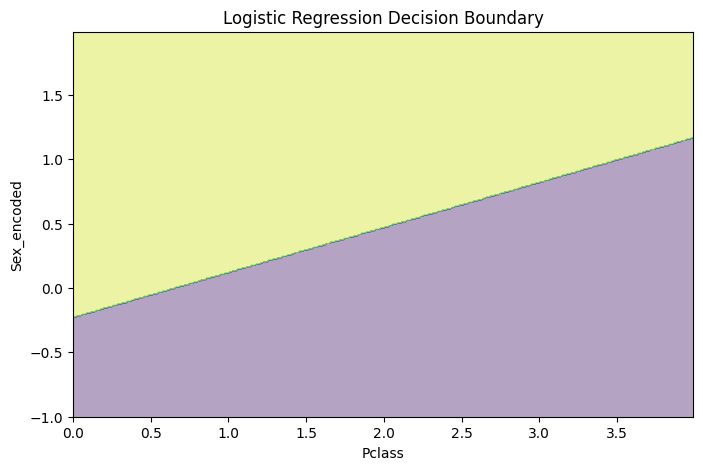

In [53]:
import matplotlib.pyplot as plt

# flatten xx, yy into pairs for model to predict on
Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

fig, ax = plt.subplots(figsize=(8,5))
ax.contourf(xx, yy, Z, alpha=0.4)
ax.scatter(X_2d['Pclass'], X_2d['Sex_encoded'], c=y_2d, edgecolors='black')
ax.set_xlabel('Pclass')
ax.set_ylabel('Sex_encoded')
ax.set_title('Logistic Regression Decision Boundary')
plt.show()

In [46]:
#5. Confusion matrix from scratch — TP, TN, FP, FN
#       t  f
# p -  TP  FP
# n  - TN  FN

confusion_matrix(y_test,y_pred)

array([[139,  28],
       [ 28,  72]])


- confusion_matrix
1. [[TN, FP],
 2. [FN, TP]]

1. Accuracy  = (TP + TN) / (TP + TN + FP + FN)    ==>
2. Precision = TP / (TP + FP)
3. Recall    = TP / (TP + FN)
4. F1        = 2 * (Precision * Recall) / (Precision + Recall)

In [47]:
# 6. Compute accuracy, precision, recall, F1
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.83      0.83      0.83       167
           1       0.72      0.72      0.72       100

    accuracy                           0.79       267
   macro avg       0.78      0.78      0.78       267
weighted avg       0.79      0.79      0.79       267



## Day -3 end

In [48]:
##practice
a = np.arange(1,4)  # [1, 2, 3]
b = np.arange(0,3)  #[0,1,2]

In [49]:
## aa, bb put together describe every possible combination
aa,bb = np.meshgrid(a,b)

In [51]:
print(aa)
print("\n",bb)

[[1 2 3]
 [1 2 3]
 [1 2 3]]

 [[0 0 0]
 [1 1 1]
 [2 2 2]]


In [52]:
#flatten aa, bb into pairs which model can predcit on
np.c_[aa.ravel(),bb.ravel()]

array([[1, 0],
       [2, 0],
       [3, 0],
       [1, 1],
       [2, 1],
       [3, 1],
       [1, 2],
       [2, 2],
       [3, 2]])